In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

****load a dataset from kaggle "https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020?utm_source=chatgpt.com"****

In [2]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")

In [3]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches.info()
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
matches.isna().sum()


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [7]:
deliveries.isna().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

****high run batsman and plot****

In [8]:
top_runs=deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
top_runs

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

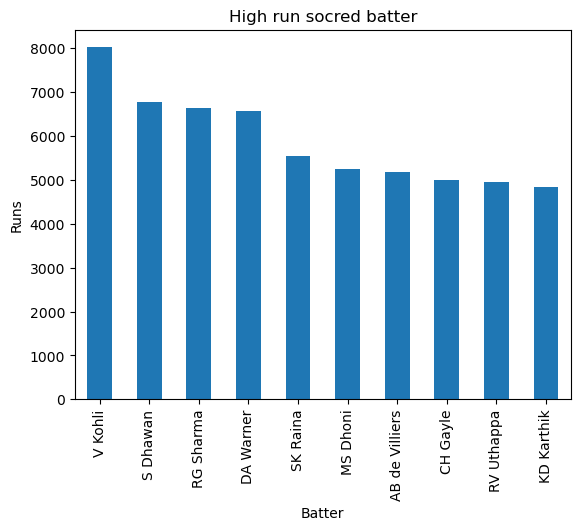

In [9]:
top_runs.plot(kind="bar")
plt.ylabel("Runs")
plt.xlabel("Batter")
plt.title("High run socred batter")
plt.show()

****high strik rate batsman and  plot****

In [10]:
player_state=deliveries.groupby("batter").agg(
   runs=("batsman_runs","sum"),
   balls=("ball","mean")
)

In [11]:
player_state["strike_rate"]=(
    player_state["runs"]/
    player_state["balls"]
)*100

In [12]:
player_state["strike_rate"].sort_values(ascending=False).head(10)

batter
V Kohli           230279.716155
S Dhawan          191726.557496
RG Sharma         187245.477332
DA Warner         186371.198642
SK Raina          152040.712736
AB de Villiers    142432.568590
MS Dhoni          140862.575727
RV Uthappa        139758.318966
CH Gayle          137540.723344
KL Rahul          134908.668382
Name: strike_rate, dtype: float64

****wining percent by team****

In [13]:
team_win=matches["winner"].value_counts()
team_win

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Punjab Kings                    24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [14]:
total_match=total_matches = (
matches['team1'].value_counts()
+
matches['team2'].value_counts()
)
total_match

Chennai Super Kings            238
Deccan Chargers                 75
Delhi Capitals                  91
Delhi Daredevils               161
Gujarat Lions                   30
Gujarat Titans                  45
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          251
Lucknow Super Giants            44
Mumbai Indians                 261
Pune Warriors                   46
Punjab Kings                    56
Rajasthan Royals               221
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    240
Royal Challengers Bengaluru     15
Sunrisers Hyderabad            182
Name: count, dtype: int64

In [15]:
win_percentage=(
    team_win/total_match
)*100
wining_percentage=win_percentage.sort_values(ascending=False)

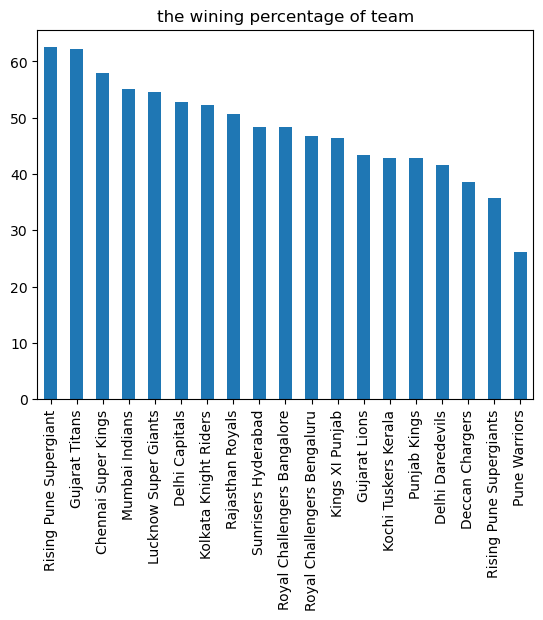

In [16]:
wining_percentage.plot(kind="bar")
plt.title("the wining percentage of team")
plt.show()

****run scored by season****

In [17]:
season_runs = deliveries.merge(
matches[['id','season']],
left_on='match_id',
right_on='id'
)

In [18]:
player_season=season_runs.groupby(
    ['season','batter']
)["batsman_runs"].sum()
player_season

season   batter           
2007/08  A Chopra              42
         A Kumble              13
         A Mishra              37
         A Mukund               0
         A Nehra                3
                             ... 
2024     WG Jacks             230
         WP Saha              136
         Washington Sundar      0
         YBK Jaiswal          435
         Yudhvir Singh         21
Name: batsman_runs, Length: 2617, dtype: int64

In [19]:
print("""A few players consistently score the highest runs.\n
Some players maintain a very high strike rate.\n
Certain teams have better win percentages.\n
Player performance changes across seasons.\n
Historical analysis helps predict future performance.""")

A few players consistently score the highest runs.

Some players maintain a very high strike rate.

Certain teams have better win percentages.

Player performance changes across seasons.

Historical analysis helps predict future performance.
